# EDA with segmented data 


purpose is also to test the modules and classes we have developed sofar 


In [13]:
import sys
import os

# Add src/ to sys.path so you can import batterydata
sys.path.append(os.path.abspath('../src'))

from batterydata.parsers.basytec_reader import BasyTecReader
from batterydata.pipeline.preprocessor import Preprocessor

In [14]:
import yaml

with open('../local_config.yaml', 'r') as f:
    config = yaml.safe_load(f)
file_path = config['basytec_sample_file']

In [15]:


# Load data
reader = BasyTecReader(filepath=file_path, sample_id="demo")
result = reader.read(nrows=1000000)
df = result['data']




In [4]:
result["data"]

,time_s,dataset_idx,step_time_s,set_time_s,line_idx,voltage_v,current_a,charge_ah,step_charge_ah,energy_wh,cycle_index,state_code
0,0.00000,1,0.00000,0.00000,2,3.832572,-0.000541,-3.552998e-08,-3.552998e-08,-1.361712e-07,1,3
1,0.00338,2,0.00338,0.00338,2,3.826466,-1.298575,-1.254026e-06,-1.254026e-06,-4.798706e-06,1,0
2,1.00237,3,1.00237,1.00237,2,3.820360,-1.299990,-3.620021e-04,-3.620021e-04,-1.383510e-03,1,1
3,2.00182,4,2.00182,2.00182,2,3.818451,-1.300017,-7.229127e-04,-7.229127e-04,-2.761937e-03,1,1
4,3.00259,5,3.00259,3.00259,2,3.816925,-1.299999,-1.084302e-03,-1.084302e-03,-4.141601e-03,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9978.12349,9996,436.00407,9978.12349,6,3.735637,1.299990,-4.637777e-01,1.574459e-01,-1.627641e+00,2,1
9996,9979.12338,9997,437.00396,9979.12338,6,3.735637,1.300008,-4.634166e-01,1.578070e-01,-1.626292e+00,2,1
9997,9980.12332,9998,438.00390,9980.12332,6,3.735637,1.300008,-4.630556e-01,1.581681e-01,-1.624943e+00,2,1
9998,9981.12262,9999,439.00320,9981.12262,6,3.735637,1.299981,-4.626947e-01,1.585289e-01,-1.623595e+00,2,1


In [16]:

# Instantiate Preprocessor and process
preproc = Preprocessor(df, cell_capacity_ah=1.3)
segmented_df, steps_df = preproc.process_all()

# Explore results
print(segmented_df.head())
print(steps_df.head())


    time_s  dataset_idx  step_time_s  set_time_s  line_idx  voltage_v  \
0  0.00000            1      0.00000     0.00000         2   3.832572   
1  0.00338            2      0.00338     0.00338         2   3.826466   
2  1.00237            3      1.00237     1.00237         2   3.820360   
3  2.00182            4      2.00182     2.00182         2   3.818451   
4  3.00259            5      3.00259     3.00259         2   3.816925   

   current_a     charge_ah  step_charge_ah     energy_wh  cycle_index  \
0  -0.000541 -3.552998e-08   -3.552998e-08 -1.361712e-07            1   
1  -1.298575 -1.254026e-06   -1.254026e-06 -4.798706e-06            1   
2  -1.299990 -3.620021e-04   -3.620021e-04 -1.383510e-03            1   
3  -1.300017 -7.229127e-04   -7.229127e-04 -2.761937e-03            1   
4  -1.299999 -1.084302e-03   -1.084302e-03 -4.141601e-03            1   

   state_code  step_type  step_number cc_cv  
0           3        OCV            1   OCV  
1           0  discharge      

In [6]:
segmented_df.head()

,time_s,dataset_idx,step_time_s,set_time_s,line_idx,voltage_v,current_a,charge_ah,step_charge_ah,energy_wh,cycle_index,state_code,step_type,step_number,cc_cv
0,0.00000,1,0.00000,0.00000,2,3.832572,-0.000541,-3.552998e-08,-3.552998e-08,-1.361712e-07,1,3,OCV,1,OCV
1,0.00338,2,0.00338,0.00338,2,3.826466,-1.298575,-1.254026e-06,-1.254026e-06,-4.798706e-06,1,0,discharge,2,CC
2,1.00237,3,1.00237,1.00237,2,3.820360,-1.299990,-3.620021e-04,-3.620021e-04,-1.383510e-03,1,1,discharge,2,CC
3,2.00182,4,2.00182,2.00182,2,3.818451,-1.300017,-7.229127e-04,-7.229127e-04,-2.761937e-03,1,1,discharge,2,CC
4,3.00259,5,3.00259,3.00259,2,3.816925,-1.299999,-1.084302e-03,-1.084302e-03,-4.141601e-03,1,1,discharge,2,CC


In [7]:
steps_df.head()


,step_number,step_type,start_time,end_time,duration_s,mean_voltage,mean_current,cc_cv_mode,discharge_cc_current,discharge_cc_duration,discharge_cc_cutoff_voltage,charge_cc_current,charge_cc_duration,charge_cc_cutoff_voltage,charge_cv_voltage,charge_cv_duration,charge_cv_cutoff_current,c_rate
0,2,discharge,0.00338,1718.25980,1718.25642,NaN,NaN,CC,-1.299035,1718.25642,2.999462,NaN,NaN,NaN,NaN,NaN,NaN,0.999258
1,3,OCV,1718.37311,2318.60555,600.23244,3.130501,-8.965060e-07,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,4,charge,2318.61005,6055.26340,3736.65335,NaN,NaN,CCCV,NaN,NaN,NaN,1.3,3362.99942,4.199133,4.200084,372.65387,0.060864,1.0
3,5,OCV,6055.37588,6065.60846,10.23258,4.199397,-9.132982e-07,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,7,discharge,6066.61191,9531.77176,3465.15985,NaN,NaN,CC,-1.299498,3465.15985,2.999462,NaN,NaN,NaN,NaN,NaN,NaN,0.999614


### Plotting CCCV 

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_step_cc_cv(
    df: pd.DataFrame,
    step_number: int,
    time_col: str = 'time_s',
    voltage_col: str = 'voltage_v',
    current_col: str = 'current_a',
    step_col: str = 'step_number',
    cc_cv_col: str = 'cc_cv'
):
    """
    Visualize CC/CV segmentation for a single step.

    - Plots voltage (top) and current (bottom) vs time for the given step.
    - Colors CC and CV points differently.
    - Draws a vertical line at the start of CV (first occurrence of cc_cv == 'CV').

    Parameters
    ----------
    df : pd.DataFrame
        Full segmented dataframe containing at least [time, voltage, current, step_number, cc_cv].
    step_number : int
        Step ID to visualize.
    time_col, voltage_col, current_col, step_col, cc_cv_col : str
        Column names in df.
    """
    step_df = df[df[step_col] == step_number].copy()
    if step_df.empty:
        print(f"[warn] No data for step_number={step_number}")
        return

    # Build masks
    cc_mask = (step_df[cc_cv_col] == 'CC')
    cv_mask = (step_df[cc_cv_col] == 'CV')

    # CV start time (first CV row in this step), if present
    if cv_mask.any():
        cv_start_time = step_df.loc[cv_mask, time_col].iloc[0]
    else:
        cv_start_time = None

    # Plot
    fig, (axV, axI) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Voltage
    if cc_mask.any():
        axV.scatter(step_df.loc[cc_mask, time_col], step_df.loc[cc_mask, voltage_col],
                    s=12, label='CC region (V)', alpha=0.9)
    if cv_mask.any():
        axV.scatter(step_df.loc[cv_mask, time_col], step_df.loc[cv_mask, voltage_col],
                    s=12, label='CV region (V)', alpha=0.9)
    if cv_start_time is not None:
        axV.axvline(cv_start_time, linestyle='--', label='CV start')

    axV.set_ylabel('Voltage (V)')
    axV.set_title(f"Step {step_number}: CC/CV segmentation (voltage & current)")
    axV.legend(loc='best')

    # Current
    if cc_mask.any():
        axI.scatter(step_df.loc[cc_mask, time_col], step_df.loc[cc_mask, current_col],
                    s=12, label='CC region (I)', alpha=0.9)
    if cv_mask.any():
        axI.scatter(step_df.loc[cv_mask, time_col], step_df.loc[cv_mask, current_col],
                    s=12, label='CV region (I)', alpha=0.9)
    if cv_start_time is not None:
        axI.axvline(cv_start_time, linestyle='--', label='CV start')

    axI.set_ylabel('Current (A)')
    axI.set_xlabel('Time (s)')
    axI.legend(loc='best')

    plt.tight_layout()
    plt.show()

# usage:
# plot_step_cc_cv(segmented_df, step_number=1234)


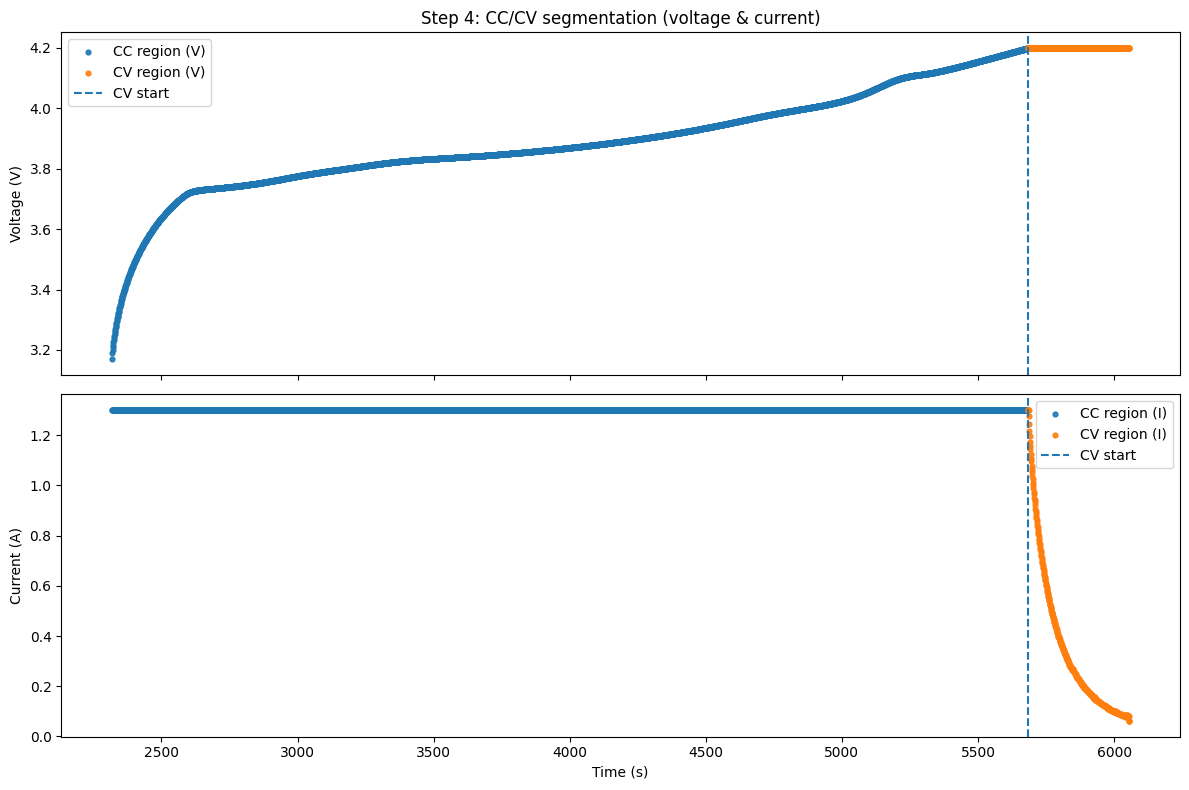

In [9]:
plot_step_cc_cv(segmented_df, step_number=4)

## Segment with Block detection 

In [17]:
seg, doe, blocks = preproc.process_with_blocks(min_block_len=4, max_block_len=4, min_repeats=2)
tables = preproc.export_tables()
segmented_df = tables["segmented_data"]
doe_table = tables["doe_table"]
metadata_table = tables["metadata"]


In [18]:
blocks

[{'block': ['DIS_1.00_V3.0_noCV'], 'count': 1, 'start': 0},
 {'block': ['OCV_600'], 'count': 1, 'start': 1},
 {'block': ['CH_1.00_V4.2_CV', 'OCV_10', 'DIS_1.00_V3.0_noCV', 'OCV_10'],
  'count': 138,
  'start': 2},
 {'block': ['CH_1.00_V3.3_noCV'], 'count': 1, 'start': 554}]

In [22]:
doe

,step_number,step_type,start_time,end_time,duration_s,mean_voltage,mean_current,cc_cv_mode,discharge_cc_current,discharge_cc_duration,...,charge_cc_current,charge_cc_duration,charge_cc_cutoff_voltage,charge_cv_voltage,charge_cv_duration,charge_cv_cutoff_current,c_rate,step_sig,block_id,cycle_number
0,2,discharge,0.00338,1718.25980,1718.25642,NaN,NaN,CC,-1.299035,1718.25642,...,NaN,NaN,NaN,NaN,NaN,NaN,0.999258,DIS_1.00_V3.0_noCV,0,1
1,3,OCV,1718.37311,2318.60555,600.23244,3.130501,-8.965060e-07,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,OCV_600,1,1
2,4,charge,2318.61005,6055.26340,3736.65335,NaN,NaN,CCCV,NaN,NaN,...,1.300000,3362.99942,4.199133,4.200084,372.65387,0.060864,1.0,CH_1.00_V4.2_CV,2,1
3,5,OCV,6055.37588,6065.60846,10.23258,4.199397,-9.132982e-07,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,OCV_10,2,1
4,7,discharge,6066.61191,9531.77176,3465.15985,NaN,NaN,CC,-1.299498,3465.15985,...,NaN,NaN,NaN,NaN,NaN,NaN,0.999614,DIS_1.00_V3.0_noCV,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,689,charge,991345.23350,995074.86967,3729.63617,NaN,NaN,CCCV,NaN,NaN,...,1.299999,3355.99897,4.198942,4.200082,372.63709,0.064169,0.999999,CH_1.00_V4.2_CV,2,138
551,690,OCV,995074.98213,995085.21460,10.23247,4.199441,-1.826596e-06,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,OCV_10,2,138
552,692,discharge,995086.21862,998536.16097,3449.94235,NaN,NaN,CC,-1.299629,3449.94235,...,NaN,NaN,NaN,NaN,NaN,NaN,0.999715,DIS_1.00_V3.0_noCV,2,138
553,693,OCV,998536.27549,998546.50812,10.23263,3.024768,0.000000e+00,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,None,OCV_10,2,138
